In [117]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score,auc
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from tensorflow.keras.datasets import cifar10

#### LR FOR CIFAR-10
 

Load the CIFAR-10 dataset

In [118]:
#Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Check the loaded data
print('Training data shape: ', x_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', x_test.shape)
print('Test labels shape: ', y_test.shape)



Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000, 1)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000, 1)


Convert the from Multi-dimension data into 1D data

In [119]:
# Convert the from 2D data into 1D
y_train = y_train.ravel()
y_test = y_test.ravel()

x_train = x_train.reshape((len(x_train), 32*32*3))
x_test = x_test.reshape((len(x_test), 32*32*3))

print('Training data shape: ', x_train.shape)
print('Test data shape: ', x_test.shape)


Training data shape:  (50000, 3072)
Test data shape:  (10000, 3072)


PCA and dimension reduction

In [120]:
# Normalization
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

pca = PCA(n_components=0.95)  # We set the n_components = 0.95 to keep most info of the dataset 
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

Divide into the training set and validation set

In [121]:
x_train_pca, x_val_pca, y_train, y_val = train_test_split(x_train_pca, y_train, test_size=0.1, random_state=50)

print('Training data shape: ', x_train_pca.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', x_test_pca.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (45000, 221)
Training labels shape:  (45000,)
Test data shape:  (10000, 221)
Test labels shape:  (10000,)


Apply the LR on the training set

In [122]:
model = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='auto', verbose=1)
model.fit(x_train_pca, y_train)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    2.3s finished


LogisticRegression(max_iter=1000, verbose=1)

Apply the test case 

Accuracy: 0.41
F1 Score: 0.41
AUC Score: 0.82


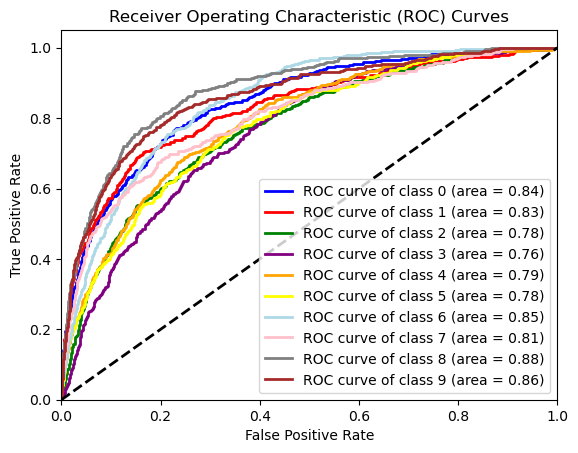

In [124]:
from sklearn.metrics import auc as compute_auc  # In order to avoid the redundence
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve

# The result of prediction
y_pred = model.predict(x_val_pca)  
y_train_pred_proba = model.predict_proba(x_train_pca)  
y_val_pred_proba = model.predict_proba(x_val_pca)  

# Evaluation
accuracy = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred, average='macro')
roc_auc = roc_auc_score(y_val, y_val_pred_proba, multi_class='ovr')

print(f"Accuracy: {accuracy:.2f}")
print(f"F1 Score: {f1:.2f}")
print(f"AUC Score: {roc_auc:.2f}")

# Plot the AUC and ROC curve
num_classes = len(np.unique(y_train))
fpr = dict()
tpr = dict()
roc_auc_values = dict()

colors = ['blue', 'red', 'green', 'purple', 'orange', 'yellow', 'lightblue', 'pink', 'gray', 'brown']
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val == i, y_val_pred_proba[:, i])
    roc_auc_values[i] = compute_auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2, label=f'ROC curve of class {i} (area = {roc_auc_values[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.show()

LR classification on MNIST


Import the required library

In [139]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
from tensorflow.keras.datasets import mnist
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve,auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import matplotlib.pyplot as plt


Load the training data set and the test data set

In [127]:
# Load data
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()


# check the size of dataset
print("Training data shape:", train_images.shape)  # (60000, 28, 28)
print("Training labels shape:", train_labels.shape) # (60000,)
print("Test data shape:", test_images.shape)        # (10000, 28, 28)
print("Test labels shape:", test_labels.shape)      # (10000,)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


Because the LR is a traditional machine learning algorithm, we need to convert image data from 2D to 1D (Flatten process)


In [128]:
x_train = train_images.reshape((60000, 28*28))
x_test = test_images.reshape((10000, 28*28))
print("Training data shape: ", x_train.shape)
print("Test data shape: ", x_test.shape)

# Normalize the pixel value from 0-255 to 0-1
x_train = x_train.astype('float32')/ 255
x_test = x_test.astype('float32')/ 255



Training data shape:  (60000, 784)
Test data shape:  (10000, 784)


Split train data into training and validation sets



In [129]:
x_train, x_val, y_train, y_val = train_test_split(x_train, train_labels, test_size=0.1, random_state=0)

Normalization Process by using StandardScaler Library

In [130]:
# Normalization
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)


Process the PCA

In [131]:
x_train_pca = pca.fit_transform(x_train_scaled)
x_val_pca = pca.transform(x_val_scaled)
x_test_pca = pca.transform(x_test_scaled)

Train the LR model

In [132]:
LR_model = LogisticRegression(max_iter=1000, solver='lbfgs', multi_class='auto', verbose=1)
LR_model.fit(x_train_pca, y_train)


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   11.7s finished


LogisticRegression(max_iter=1000, verbose=1)

Apply the LR on validation set

Validation accuracy: 92.85%
Validation F1 score: 0.93
Validation AUC score: 0.99


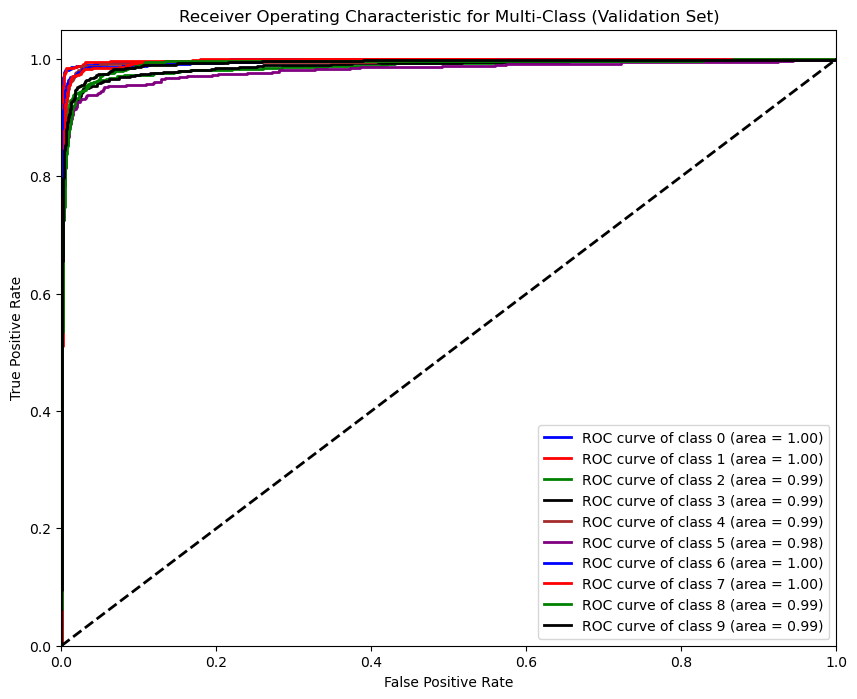

In [141]:
y_val_pred = LR_model.predict(x_val_pca)  
y_val_pred_proba = LR_model.predict_proba(x_val_pca)  

val_accuracy = accuracy_score(y_val, y_val_pred)
print("Validation accuracy: {:.2f}%".format(val_accuracy * 100))

val_f1 = f1_score(y_val, y_val_pred, average='macro')
print("Validation F1 score: {:.2f}".format(val_f1))

y_val_bin = label_binarize(y_val, classes=np.unique(y_val))  
if y_val_pred_proba.shape[1] == 2:  
    val_auc = roc_auc_score(y_val_bin, y_val_pred_proba[:, 1])  
else:  
    val_auc = roc_auc_score(y_val_bin, y_val_pred_proba, multi_class='ovr')
print("Validation AUC score: {:.2f}".format(val_auc))

n_classes = len(np.unique(y_val))
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_val_bin[:, i], y_val_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

colors = cycle(['blue', 'red', 'green', 'black', 'brown', 'purple'])

plt.figure(figsize=(10, 8))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)  
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multi-Class (Validation Set)')
plt.legend(loc="lower right")
plt.show()

Apply LR on test dataset

In [137]:
y_test_pred = LR_model.predict(x_test_pca)  
y_test_pred_proba = LR_model.predict_proba(x_test_pca)  

test_accuracy = accuracy_score(y_test, y_test_pred)
print("Test accuracy: {:.2f}%".format(test_accuracy * 100))

test_f1 = f1_score(y_test, y_test_pred, average='macro')  
print("Test F1 score: {:.2f}".format(test_f1))

y_test_bin = label_binarize(y_test, classes=np.unique(y_test))  

if y_test_pred_proba.shape[1] == 2:  
    test_auc = roc_auc_score(y_test_bin, y_test_pred_proba[:, 1])  
else:  
    test_auc = roc_auc_score(y_test_bin, y_test_pred_proba, multi_class='ovr')
print("Test AUC score: {:.2f}".format(test_auc))

Test accuracy: 9.91%
Test F1 score: 0.10
Test AUC score: 0.50


ROC Curve for Test dataset

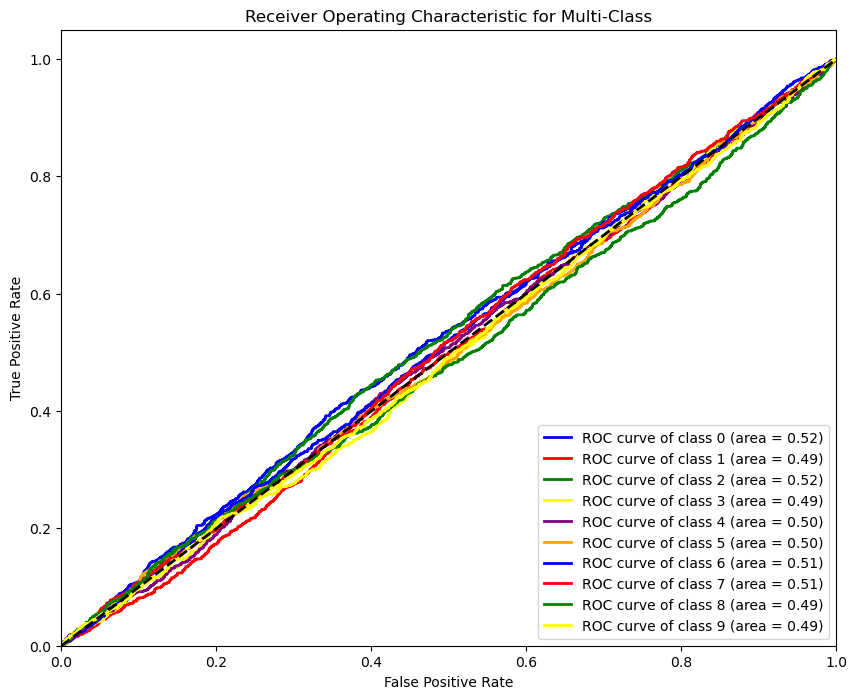

In [140]:
# find the size of unique label
n_classes = len(np.unique(y_test))

# binarize the label
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
y_test_pred_proba = LR_model.predict_proba(x_test_pca)

# Calculate the curve
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_test_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

colors = cycle(['blue', 'red', 'green', 'yellow', 'purple', 'orange'])

#Plot the curve
plt.figure(figsize=(10, 8))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multi-Class')
plt.legend(loc="lower right")
plt.show()


Iyer analysis 


Libraries

In [176]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve,auc
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, KFold


Load data


In [179]:
def load_file_helper(file):
    data = pd.read_csv(file, header=None, delimiter='\s+')
    x = data.iloc[:, 2:].values  
    y = data.iloc[:, 1].values   
    
    # filter the noise value such as label is -1
    valid_indices = (y != -1)
    x = x[valid_indices]
    update_y = y[valid_indices]
    
    print("Unique classes:", np.unique(update_y))
    
    return x, update_y

Load the test dataset

In [180]:
path = 'Datasets/iyer.txt'
x, y = load_file_helper(path)


Unique classes: [ 1  2  3  4  5  6  7  8  9 10]


Normalization

In [172]:
scaler = StandardScaler()


Dimension reduction

In [173]:
pca = PCA(n_components=0.95)

Apply the LR

In [191]:
# Initialize logistic regression model
LR_Iyer_model = LogisticRegression(max_iter = 1000, solver = 'liblinear',multi_class= 'ovr')

kf = KFold(n_splits=6, shuffle=True, random_state=0)

accuracies = []
f1_scores = []
auc_scores = []

# Assume x, y contains your data and labels
for train_index, test_index in kf.split(x):
    x_train, x_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Process normalization and PCA
    scaler = StandardScaler()
    pca = PCA(n_components=0.95)

    x_train = scaler.fit_transform(x_train)
    x_train = pca.fit_transform(x_train)
    x_test = scaler.transform(x_test)
    x_test = pca.transform(x_test)
    
    # Training the model
    LR_Iyer_model.fit(x_train, y_train)
    y_pred = LR_Iyer_model.predict(x_test)
    y_pred_proba = LR_Iyer_model.predict_proba(x_test)

    # Evaluation
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    f1_score_v = f1_score(y_test, y_pred, average='macro')
    f1_scores.append(f1_score_v)
    auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
    auc_scores.append(auc)

mean_accuracy = np.mean(accuracies)
mean_f1 = np.mean(f1_scores)
mean_auc_score = np.mean(auc_scores)

print(f"Mean Accuracy: {mean_accuracy:.2f}")
print(f"Mean F1 Score: {mean_f1:.2f}")
print(f"Mean AUC: {mean_auc_score:.2f}")

Mean Accuracy: 0.70
Mean F1 Score: 0.47
Mean AUC: 0.95


In [192]:
# Initialize logistic regression model
LR_Iyer_model = LogisticRegression(max_iter = 1000, solver = 'liblinear',multi_class= 'ovr')

kf = KFold(n_splits=3, shuffle=True, random_state=0)

accuracies = []
f1_scores = []
auc_scores = []

# Assume x, y contains your data and labels
for train_index, test_index in kf.split(x):
    x_train, x_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Process normalization and PCA
    scaler = StandardScaler()
    pca = PCA(n_components=0.95)

    x_train = scaler.fit_transform(x_train)
    x_train = pca.fit_transform(x_train)
    x_test = scaler.transform(x_test)
    x_test = pca.transform(x_test)
    
    # Training the model
    LR_Iyer_model.fit(x_train, y_train)
    y_pred = LR_Iyer_model.predict(x_test)
    y_pred_proba = LR_Iyer_model.predict_proba(x_test)

    # Evaluation
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    f1_score_v = f1_score(y_test, y_pred, average='macro')
    f1_scores.append(f1_score_v)
    auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
    auc_scores.append(auc)

mean_accuracy = np.mean(accuracies)
mean_f1 = np.mean(f1_scores)
mean_auc_score = np.mean(auc_scores)

print(f"Mean Accuracy: {mean_accuracy:.2f}")
print(f"Mean F1 Score: {mean_f1:.2f}")
print(f"Mean AUC: {mean_auc_score:.2f}")

Mean Accuracy: 0.69
Mean F1 Score: 0.46
Mean AUC: 0.95
